# Logistic Regression (Loan Approval Prediction) Assignment

### Q1. Data Loading & Understanding

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column.

In [26]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("C:\\Users\\DivyaTejAtluri\\Downloads\\loan_approval - loan_approval.csv")

# Display first 5 rows
df.head()

# Shape of dataset
print("Shape:", df.shape)

# Data types
print(df.dtypes)

Shape: (2000, 8)
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


### Q2. Data Cleaning

a) Check for missing values in the dataset.

b) Handle missing values appropriately.

c) Identify categorical columns present in the dataset.

In [27]:
# Missing values
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0])
    else:
        df[col].fillna(df[col].median())

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", cat_cols)

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64
Categorical Columns: Index(['name', 'city'], dtype='object')


### Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable. 

b) Analyze the relationship between one numerical feature and the target variable. 

c) Analyze the relationship between Years of Employment and the target variable.

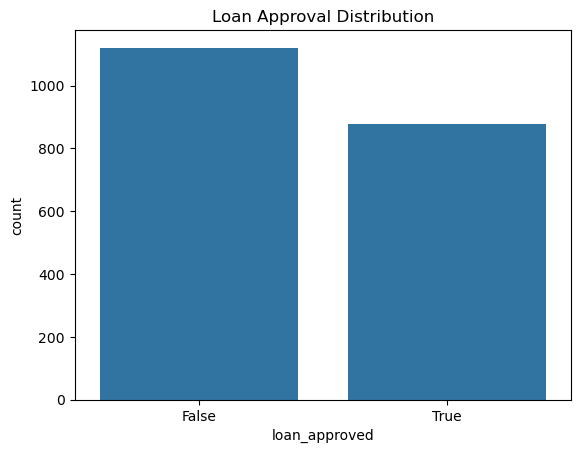

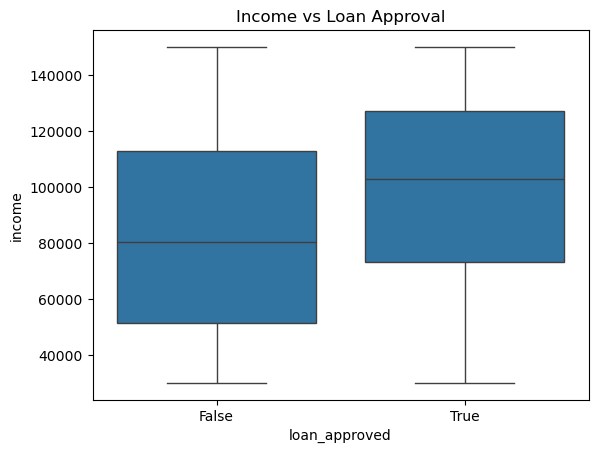

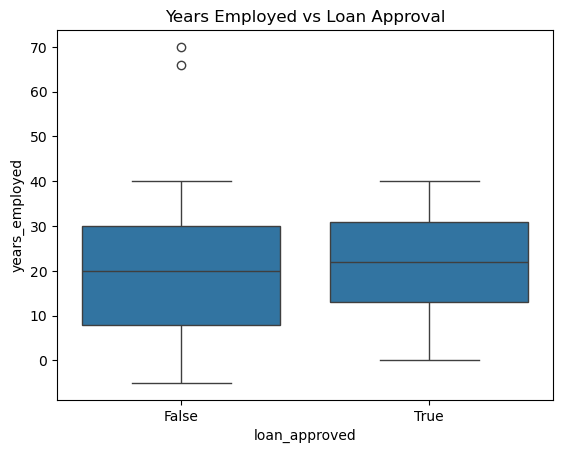

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable distribution
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Relationship: Income vs Loan Approval
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title("Income vs Loan Approval")
plt.show()

# Years Employed vs Loan Approval
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years Employed vs Loan Approval")
plt.show()

### Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.

b) Treat outliers using capping techniques

In [29]:
num_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n🔹 Column: {col}")
    print(f"Lower Bound: {lower}, Upper Bound: {upper}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    print(outliers[[col]].head())   


🔹 Column: income
Lower Bound: -26909.0, Upper Bound: 208305.0
Number of Outliers: 0
Empty DataFrame
Columns: [income]
Index: []

🔹 Column: credit_score
Lower Bound: 8.5, Upper Bound: 1140.5
Number of Outliers: 3
     credit_score
10           1285
108          6548
114          6110

🔹 Column: loan_amount
Lower Bound: -24198.875, Upper Bound: 74328.125
Number of Outliers: 0
Empty DataFrame
Columns: [loan_amount]
Index: []

🔹 Column: years_employed
Lower Bound: -21.5, Upper Bound: 62.5
Number of Outliers: 2
     years_employed
8                66
401              70

🔹 Column: points
Lower Bound: 7.5, Upper Bound: 107.5
Number of Outliers: 0
Empty DataFrame
Columns: [points]
Index: []


In [30]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Apply capping
    df[col] = df[col].clip(lower, upper)

print("\n After Capping (Summary Statistics):")
print(df[num_cols].describe())


 After Capping (Summary Statistics):
              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    574.546250  25308.503000       20.476500    56.680000
std     34487.874907    162.442674  14207.320147       11.852993    18.638033
min     30053.000000     11.000000   1022.000000       -5.000000    10.000000
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000
75%    120099.750000    716.000000  37380.500000       31.000000    70.000000
max    149964.000000   1140.500000  49999.000000       62.500000   100.000000


In [31]:
# Before vs After comparison
print("Before Capping:")
print(df[num_cols].describe())

# (Run capping here)

print("\nAfter Capping:")
print(df[num_cols].describe())

Before Capping:
              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    574.546250  25308.503000       20.476500    56.680000
std     34487.874907    162.442674  14207.320147       11.852993    18.638033
min     30053.000000     11.000000   1022.000000       -5.000000    10.000000
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000
75%    120099.750000    716.000000  37380.500000       31.000000    70.000000
max    149964.000000   1140.500000  49999.000000       62.500000   100.000000

After Capping:
              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    574.546250  25308.503000       20.476500    56.680000
std     34487.874907    162.4426

### Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [32]:
df.drop(columns=['name'], inplace=True)

In [33]:
print("Columns after dropping:")
print(df.columns)

Columns after dropping:
Index(['city', 'income', 'credit_score', 'loan_amount', 'years_employed',
       'points', 'loan_approved'],
      dtype='object')


In [34]:
df.head()

,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,East Jill,113810,389.0,39698,27.0,50,False
1,New Jamesside,44592,729.0,15446,28.0,55,False
2,Lake Roberto,33278,584.0,11189,13.0,45,False
3,West Melanieview,127196,344.0,48823,29.0,50,False
4,Mariastad,66048,496.0,47174,4.0,25,False


### Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).

b) Split the dataset into training and testing sets. 

In [35]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
print(X.shape)
print(y.shape)

(2000, 1886)
(2000,)


In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 1886)
(400, 1886)
(1600,)
(400,)


### Q7. Apply feature scaling to the dataset using StandardScaler.

In [41]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df.head()

,income,credit_score,loan_amount,years_employed,points,city_Adamburgh,city_Adamland,city_Adammouth,city_Adamsfort,city_Adamsfurt,...,city_Wilsonton,city_Wilsonview,city_Wongburgh,city_Woodsburgh,city_Wrightchester,city_Yatesbury,city_Youngbury,city_Yumouth,city_Zacharyton,city_Zamoramouth
0,-1.170183,-0.675556,-0.217638,0.287341,-1.675295,-0.025008,-0.025008,-0.025008,-0.025008,-0.025008,...,0.0,-0.025008,0.0,-0.025008,-0.025008,-0.025008,-0.025008,0.0,-0.025008,-0.025008
1,-0.580842,-0.406630,-0.200153,-1.310750,-1.145034,-0.025008,-0.025008,-0.025008,-0.025008,-0.025008,...,0.0,-0.025008,0.0,-0.025008,-0.025008,-0.025008,-0.025008,0.0,-0.025008,-0.025008
2,-0.055065,1.365836,-0.536250,0.035011,1.506274,-0.025008,-0.025008,-0.025008,-0.025008,-0.025008,...,0.0,-0.025008,0.0,-0.025008,-0.025008,-0.025008,-0.025008,0.0,-0.025008,-0.025008
3,-0.574118,-1.268416,-0.858543,0.707891,-0.614772,-0.025008,-0.025008,-0.025008,-0.025008,-0.025008,...,0.0,-0.025008,0.0,-0.025008,-0.025008,-0.025008,-0.025008,0.0,-0.025008,-0.025008
4,0.180173,1.151918,-1.203347,-1.226640,1.506274,-0.025008,-0.025008,-0.025008,-0.025008,-0.025008,...,0.0,-0.025008,0.0,-0.025008,-0.025008,-0.025008,-0.025008,0.0,-0.025008,-0.025008


### Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.

b) Predict the output for test data.

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("First 10 Predictions (y_pred):")
print(y_pred[:10])

print("\nFirst 10 Probabilities (y_prob):")
print(y_prob[:10])

First 10 Predictions (y_pred):
[False  True  True  True  True False  True  True False  True]

First 10 Probabilities (y_prob):
[0.05510283 0.99891632 0.97756258 0.84744467 0.99038478 0.17877319
 0.67812551 0.98291479 0.08647089 0.95173923]


### Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.

b) Interpret the results.

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[207  10]
 [ 24 159]]

Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.95      0.92       217
        True       0.94      0.87      0.90       183

    accuracy                           0.92       400
   macro avg       0.92      0.91      0.91       400
weighted avg       0.92      0.92      0.91       400



### Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.
    
b) Calculate the AUC score.

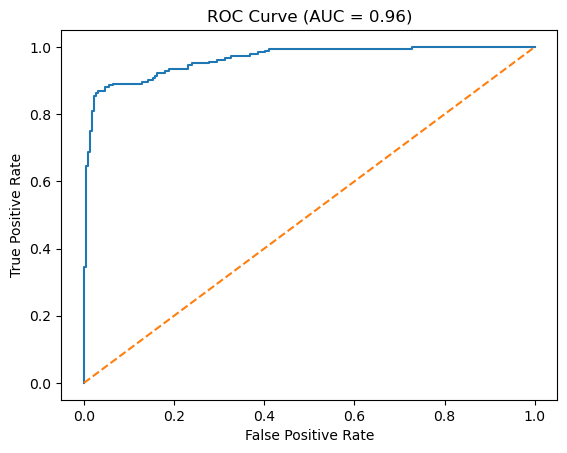

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()